In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
data_dir = os.getcwd() + '/data/20190702 P/'

In [2]:
data_1 = np.loadtxt(data_dir + '20190702P_1.CSV', delimiter=';')
data_1[:,1] /= 100
data_2 = np.loadtxt(data_dir + '20190702P_2.CSV', delimiter=';')
data_2[:,1] /= 100
data_3 = np.loadtxt(data_dir + '20190702P_3.CSV', delimiter=';')
data_3[:,1] /= 100
data_sub = np.loadtxt(data_dir + '20190702P_substrate.CSV', delimiter=';')
data_sub[:,1] /= 100

## Transmittances

### Manual input

<IPython.core.display.Javascript object>


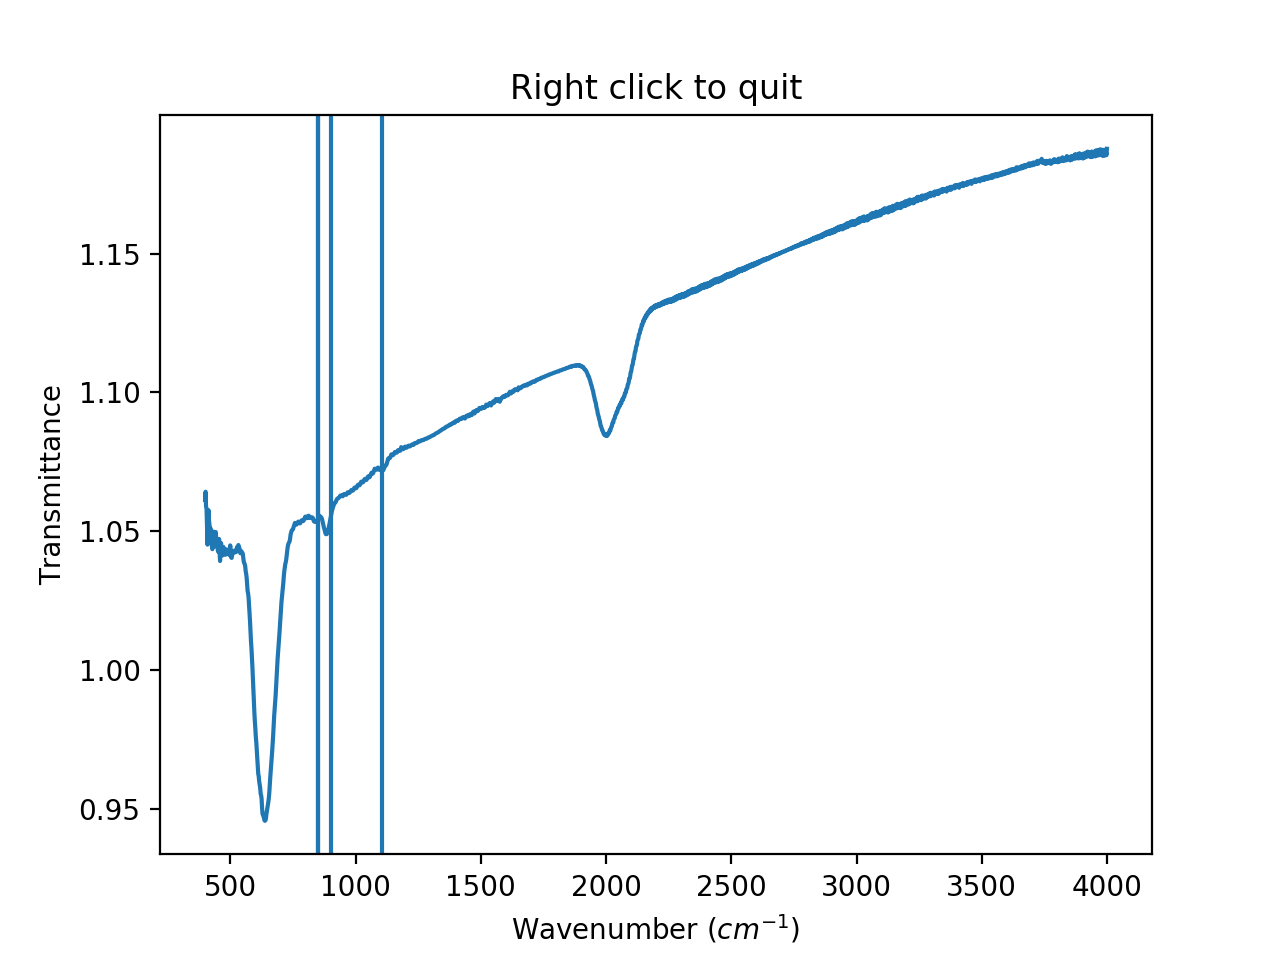

In [3]:
def find_nearest(a, a0):
    "Element in nd array `a` closest to the scalar value `a0`"
    idx = np.abs(a - a0).argmin()
    return idx

def draw_background(subdata, data):
    %matplotlib notebook
    fig, ax = plt.subplots()
    ax.plot(data[:,0], data[:,1] / subdata[:,1])
    ax.set_title("Right click to quit")
    ax.set_xlabel(r'Wavenumber ($cm^{-1}$)')
    ax.set_ylabel('Transmittance')
    ax.axvline(850)
    ax.axvline(900)
    ax.axvline(850)
    ax.axvline(1107)

    coords = []
    def onclick(event):
        global coords
        if event.button.name == 'LEFT':
            x = event.xdata
            idx = find_nearest(data[:,0], x)
            ax.scatter(data[:,0][idx],(data[:,1]/ subdata[:,1])[idx], color='k')
            coords.append(idx)

        if event.button.name == 'RIGHT':
            fig.canvas.mpl_disconnect(cid)

    cid = fig.canvas.mpl_connect('button_press_event', onclick)
    
    return coords
    
coords = draw_background(data_sub, data_1)

In [15]:
coords

[67, 187, 758, 924]

## Plot transmittances

Text(0, 0.5, 'Transmittance')

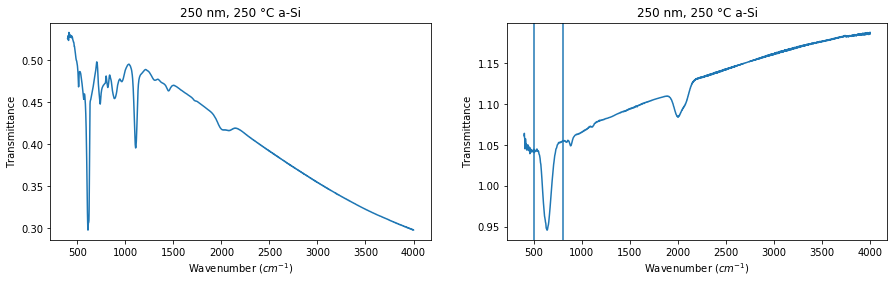

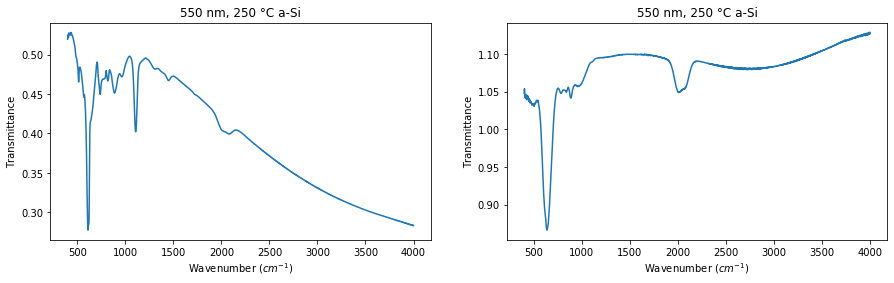

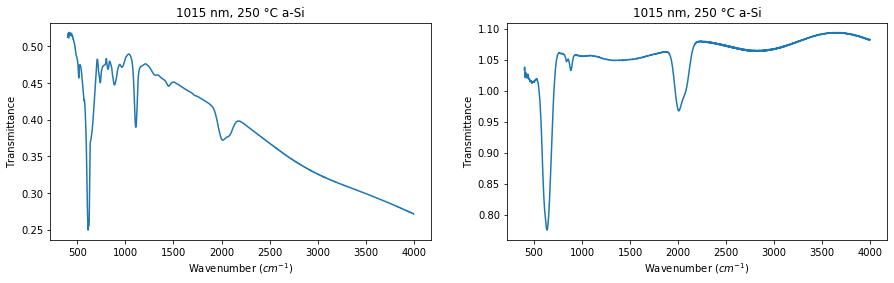

In [17]:
%matplotlib inline
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(data_1[:,0], data_1[:,1])
ax1.set_title("250 nm, 250 °C a-Si")
ax1.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax1.set_ylabel('Transmittance')
ax2.plot(data_1[:,0], data_1[:,1]/data_sub[:,1])
ax2.set_title("250 nm, 250 °C a-Si")
ax2.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax2.set_ylabel('Transmittance')
ax2.axvline(500)
ax2.axvline(800)

fig, (ax1,ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(data_2[:,0], data_2[:,1])
ax1.set_title("550 nm, 250 °C a-Si")
ax1.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax1.set_ylabel('Transmittance')
ax2.plot(data_2[:,0], data_2[:,1]/data_sub[:,1])
ax2.set_title("550 nm, 250 °C a-Si")
ax2.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax2.set_ylabel('Transmittance')

fig, (ax1,ax2) = plt.subplots(1,2, figsize = (15,4))
ax1.plot(data_3[:,0], data_3[:,1])
ax1.set_title("1015 nm, 250 °C a-Si")
ax1.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax1.set_ylabel('Transmittance')
ax2.plot(data_3[:,0], data_3[:,1]/data_sub[:,1])
ax2.set_title("1015 nm, 250 °C a-Si")
ax2.set_xlabel(r'Wavenumber ($cm^{-1}$)')
ax2.set_ylabel('Transmittance')

## Data analysis

In [ ]:
from FTIR_fitting import fit_FTIR
fit_FTIR(data_1 / data_sub, 250)

In [ ]:
from FTIR_fitting import fit_FTIR
fit_FTIR(data_2 / data_sub, 550)

In [ ]:
from FTIR_fitting import fit_FTIR
fit_FTIR(data_3, 1015)

In [ ]:
import numpy as np
from scipy.optimize import curve_fit
T0 = 0.54
t = 237

Tmeas = 0.5

p0 = 1e-3
def T(t,a):
    return 4*T0**2*np.exp(-a*t)/((1+T0)**2 - (1-T0)**2 * np.exp(-2*a*t))

popt, pcov = curve_fit(T, t, Tmeas, p0=p0)

absorbance = np.log10(1/Tmeas)
absorption_coeff = 2.303*absorbance/t

In [ ]:
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.integrate import trapz

# Define Brodsky method
def alpha(T, T0, d):
    return np.log((2*T0**2 + (T**2*T0**4-2*T**2*T0**2+T**2+4*T0**4)**0.5)/(T*T0**2+2*T*T0+T))/d

# Get T0
x0_max = data_sub[:,0][np.argmax(data_sub[:,1])]
y0_max = data_sub[:,1][np.argmax(data_sub[:,1])]
x0_min = 1500
y0_min = data_sub[:,1][np.argmax(data_sub[:,0] >= x0_min)]

x0_interp = np.array([x0_max, x0_min])
y0_interp = np.array([y0_max, y0_min])
y0_func = interp1d(x0_interp,y0_interp)
y0_func2 = interp1d()

plt.figure()
plt.plot(data_sub[:,0], data_sub[:,1])
plt.plot(x0_interp, y0_func(x0_interp))
    
data = np.copy(data_1)
thickness = 250
show_windows = True

thickness *= 1e-7 # convert from nm to cm
x = data[:,0]
absorbance = np.log10(1/data[:,1])

y = data[:,1] / data_sub[:,1]
y0 = data[:,1]
#absorption_coeff = 2.303*absorbance/thickness 
#y = absorption_coeff

# Coarse window selection
peak1_window = [500,800]
peak1_x = x[np.logical_and(x>peak1_window[0], x<peak1_window[1])]
peak1_y = y[np.logical_and(x>peak1_window[0], x<peak1_window[1])]
peak1_y0 = y0[np.logical_and(x>peak1_window[0], x<peak1_window[1])]

peak2_window = [1800,2250]
peak2_x = x[np.logical_and(x>peak2_window[0], x<peak2_window[1])]
peak2_y = y[np.logical_and(x>peak2_window[0], x<peak2_window[1])]
peak2_y0 = y[np.logical_and(x>peak2_window[0], x<peak2_window[1])]

In [ ]:
# Baseline correction
x1_interp = np.array([peak1_x[0], peak1_x[-1]])
y1_interp = np.array([peak1_y[0], peak1_y[-1]])
y01_interp = np.array([peak1_y0[0], peak1_y0[-1]])
y_spline1_func = interp1d(x1_interp,y1_interp)
y0_spline1_func = interp1d(x1_interp,y01_interp)
y_spline1 = y_spline1_func(peak1_x)
y0_spline1 = y0_spline1_func(peak1_x)
c_peak1_y = peak1_y - y_spline1

if show_windows == True:
    fig,ax = plt.subplots(figsize=(16.5,6))
    ax.plot(peak1_x,peak1_y)
    ax.plot(peak1_x,y_spline1)

x2_interp = np.array([peak2_x[0], peak2_x[-1]])
y2_interp = np.array([peak2_y[0], peak2_y[-1]])
y_spline2_func = interp1d(x2_interp,y2_interp)
y_spline2 = y_spline2_func(peak2_x)
c_peak2_y = peak2_y - y_spline2

if show_windows == True:
    fig,ax = plt.subplots(figsize=(16.5,6))
    ax.plot(peak2_x,peak2_y)
    ax.plot(peak2_x,y_spline2)
    
# Calculate absorption coefficients
a1 = alpha(peak1_y,y0_spline1,thickness)

fig,ax = plt.subplots(figsize=(16.5,6))
ax.plot(peak1_x,peak1_y)
ax.set_title('T')

fig,ax = plt.subplots(figsize=(16.5,6))
ax.plot(peak1_x,y0_spline1)
ax.set_title('T0')


fig,ax = plt.subplots(figsize=(16.5,6))
ax.plot(peak1_x,a1)
ax.set_title('absorption coeff')

# Fitting LSM-HSM
def gaussian(x,mu,sigma,a):
    y = a*np.exp(-0.5*((x-mu)/sigma)**2)
    return y

def model(x, mu2000, sigma2000, a2000, mu2080, sigma2080, a2080):
    y = gaussian(x,mu2000,sigma2000,a2000)  + gaussian(x,mu2080,sigma2080,a2080)
    return y

p0 = [2000,10,1e3, 2080,10,1e3]
#bounds = ([1950,0,0, 2050,0,0],[2005,np.inf,np.inf, 2150, np.inf, np.inf])
popt2, pcov2 = curve_fit(model, peak2_x, c_peak2_y, p0=p0)

fig, ax = plt.subplots(figsize=(16.5,6))
ax.scatter(peak2_x,c_peak2_y,s=2)
ax.plot(peak2_x, model(peak2_x,*popt2))
ax.plot(peak2_x, gaussian(peak2_x,popt2[0],popt2[1],popt2[2]), alpha=0.5)
ax.plot(peak2_x, gaussian(peak2_x,popt2[3],popt2[4],popt2[5]), alpha=0.5)

# Fitting content peak
p0 = [640,10,1e3]
#bounds = ([1950,0,0, 2050,0,0],[2005,np.inf,np.inf, 2150, np.inf, np.inf])
popt1, pcov1 = curve_fit(gaussian, peak1_x, c_peak1_y, p0=p0)

fig, ax = plt.subplots(figsize=(16.5,6))
ax.scatter(peak1_x,c_peak1_y,s=2)
ax.plot(peak1_x, gaussian(peak1_x,*popt1))

# Calculate microstructure parameter R
xpoints = np.linspace(peak2_window[0],peak2_window[1], num=1000)
dx = xpoints[1] - xpoints[0]
I_2000 = trapz(gaussian(xpoints,popt2[0],popt2[1],popt2[2])/xpoints, xpoints, dx=dx)
I_2080 = trapz(gaussian(xpoints,popt2[3],popt2[4],popt2[5])/xpoints, xpoints, dx=dx)
R = I_2080/(I_2080 + I_2000)
print('R: ' + str(R))

# Calculate hydrogen content
xpoints = np.linspace(peak1_window[0],peak1_window[1], num=1000)
dx = xpoints[1] - xpoints[0]
A = 1.6*10**19
N = 5*10**22
C = A/N * trapz(gaussian(xpoints,*popt1)/xpoints, xpoints, dx=dx)
print('C: ' + str(C))
    

In [ ]:
# Eq test

def alpha(T, T0, t):
    return -2*T0+np.sqrt(4*T0**2-T**2*(1-T0)**2*(1+T0)**2)

In [ ]:
x**2

In [ ]:
alpha(0.95,0.54,2)

In [ ]:
np.log(-1.17)

In [ ]:
-2*T0

In [ ]:
4*T0**2-T**2*(1-T0)**2*(1+T0)**2

In [ ]:
4*T0**2

In [ ]:
T**2

In [ ]:
-2*T0 + np.sqrt(4*T0**2 - T**2 * (1-T0)**2 * (1+T0)**2)

In [ ]:
(1+T0)**2

In [ ]:
def Tf(a, T0, d):
    return 4*T0**2 * np.exp(-a*d) / ((1+T0)**2 - (1-T0)**2 * np.exp(-2*a*d))

In [ ]:
Tff = Tf(0.005, 0.54, 1)
Tff

In [ ]:
def alpha(T, T0, d):
    return np.log((2*T0**2 + (T**2*T0**4-2*T**2*T0**2+T**2+4*T0**4)**0.5)/(T*T0**2+2*T*T0+T))/d

In [ ]:
alpha(Tff, 0.54 , 1)

In [ ]:
x

In [ ]:
np.argmax(x>403)

In [ ]:
np.zeros(7)

In [ ]:
%matplotlib notebook
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(-10,10)
y = x**2

fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(x,y)

coords = []
def onclick(event):
    x = event.xdata
    ax.scatter(x,40, color='k')

    global coords
    if event.button.name == 'LEFT':
        coords.append(x)
        
    if event.button.name == 'RIGHT':
        fig.canvas.mpl_disconnect(cid)

cid = fig.canvas.mpl_connect('button_press_event', onclick)


In [ ]:
coords

In [ ]:
a

In [ ]:
a[0].name